In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
sqft = [800, 950, 1100, 1200, 1350, 1500, 1650, 1800, 2000, 2200,
 900, 1050, 1250, 1400, 1600, 1750, 1900, 2100, 1150, 1300]
price = [42, 48, 54, 58, 65, 73, 79, 88, 96, 105,
 45, 52, 60, 68, 76, 84, 91, 100, 56, 63]
df = pd.DataFrame({"size_sqft":sqft, "price_lakh":price})
df.head()

,size_sqft,price_lakh
0,800,42
1,950,48
2,1100,54
3,1200,58
4,1350,65


In [ ]:
df.tail()

,size_sqft,price_lakh
15,1750,84
16,1900,91
17,2100,100
18,1150,56
19,1300,63


In [ ]:
df.sample(10)

,size_sqft,price_lakh
2,1100,54
14,1600,76
15,1750,84
6,1650,79
8,2000,96
16,1900,91
18,1150,56
5,1500,73
17,2100,100
19,1300,63


In [ ]:
df.describe()

,size_sqft,price_lakh
count,20.000000,20.000000
mean,1447.500000,70.150000
std,413.736186,19.027058
min,800.000000,42.000000
25%,1137.500000,55.500000
50%,1375.000000,66.500000
75%,1762.500000,85.000000
max,2200.000000,105.000000


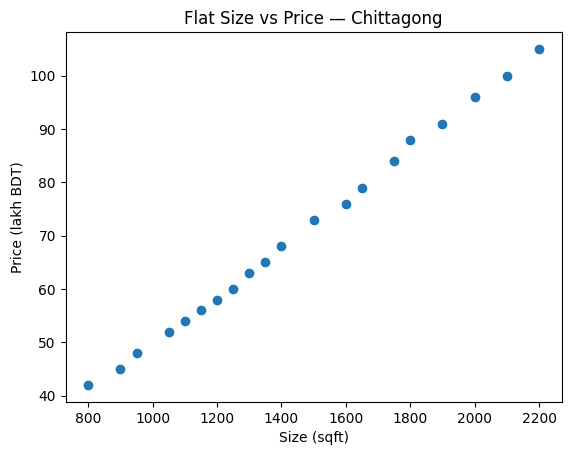

In [ ]:
plt.scatter(df["size_sqft"], df["price_lakh"])
plt.xlabel("Size (sqft)")
plt.ylabel("Price (lakh BDT)")
plt.title("Flat Size vs Price — Chittagong")
plt.show()

In [ ]:
X = df[["size_sqft"]]
y = df["price_lakh"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(16, 1) (16,)
(4, 1) (4,)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([ 39.7763745 , 100.47319065,  84.13174015,  46.77985329])

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mae

1.0121757543673926

In [ ]:
r2_score(y_test, y_pred)

0.9971658032979072

In [ ]:
rmse = np.sqrt(mae)
rmse

np.float64(1.0060694580233478)

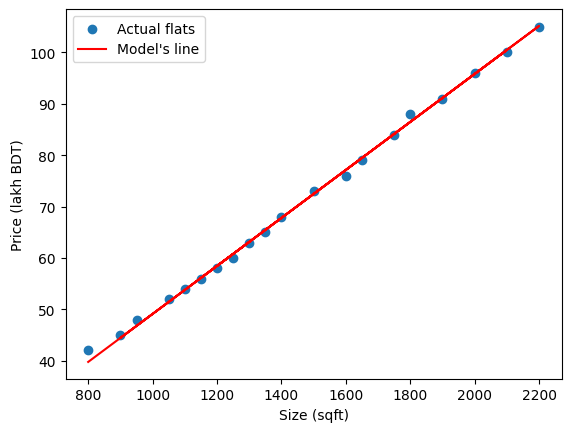

In [ ]:
plt.scatter(X, y, label="Actual flats")
plt.plot(X, model.predict(X), color="red", label="Model's line")
plt.xlabel("Size (sqft)")
plt.ylabel("Price (lakh BDT)")
plt.legend()
plt.show()

In [ ]:
new_flat = pd.DataFrame({"size_sqft": [134]})
new_flat

,size_sqft
0,134


In [ ]:
model.predict(new_flat)

array([8.68092868])

1. **Add 'bedrooms' feature**

In [ ]:
sqft = [800, 950, 1100, 1200, 1350, 1500, 1650, 1800, 2000, 2200,
 900, 1050, 1250, 1400, 1600, 1750, 1900, 2100, 1150, 1300]
price = [42, 48, 54, 58, 65, 73, 79, 88, 96, 105,
 45, 52, 60, 68, 76, 84, 91, 100, 56, 63]
bedrooms = [2, 2, 3, 3, 3, 4, 4, 4, 5, 5,
            2, 3, 3, 3, 4, 4, 4, 5, 3, 3]
df1 = pd.DataFrame({"size_sqft":sqft, "price_lakh":price,"bedrooms":bedrooms})
df1.head()

,size_sqft,price_lakh,bedrooms
0,800,42,2
1,950,48,2
2,1100,54,3
3,1200,58,3
4,1350,65,3


**Model Retrain**

In [ ]:
X_1=df1[["size_sqft","bedrooms"]]
y_1=df1["price_lakh"]

In [ ]:
X_1train, X_1test, y_1train, y_1test = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

In [ ]:
print(X_1train.shape, y_1train.shape)
print(X_1test.shape, y_1test.shape)

(16, 2) (16,)
(4, 2) (4,)


In [ ]:
model1=LinearRegression()
model1.fit(X_1train,y_1train)

LinearRegression()

In [ ]:
y_1pred = model1.predict(X_1test)
y_1pred

array([ 39.78802568, 100.45820778,  84.14044281,  46.818158  ])

In [ ]:
mae1 = mean_absolute_error(y_1test, y_1pred)
mae1

0.9981167299882152

In [ ]:
mae_diff = mae-mae1
mae_diff

0.014059024379177387

**Summary Report after adding the bedrooms.**

As observed, the Mean Absolute Error (MAE) decreased from approximately 1.012 to 0.998 after including the 'bedrooms' feature in the model. This represents a reduction of 0.014 in MAE.

This decrease indicates that the model's predictions are, on average, closer to the actual house prices when 'bedrooms' is considered as an additional predictor. The model has become more accurate in its estimations.

**Add one absurd row and retrain**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Original Data:
sqft = [800, 950, 1100, 1200, 1350, 1500, 1650, 1800, 2000, 2200,
 900, 1050, 1250, 1400, 1600, 1750, 1900, 2100, 1150, 1300]
price = [42, 48, 54, 58, 65, 73, 79, 88, 96, 105,
 45, 52, 60, 68, 76, 84, 91, 100, 56, 63]
df_original = pd.DataFrame({"size_sqft":sqft, "price_lakh":price})

# Add absurd row
absurd_row = pd.DataFrame([{"size_sqft": 500, "price_lakh": 900}])
df_absurd = pd.concat([df_original, absurd_row], ignore_index=True)
df_absurd.tail()

,size_sqft,price_lakh
16,1900,91
17,2100,100
18,1150,56
19,1300,63
20,500,900


In [ ]:
X_absurd = df_absurd[['size_sqft']]
y_absurd = df_absurd['price_lakh']

In [ ]:
X_train_absurd, X_test_absurd, y_train_absurd, y_test_absurd = train_test_split(X_absurd, y_absurd, test_size=0.2, random_state=42)

In [ ]:
# Retrain a new Linear Regression model
model_absurd = LinearRegression()
model_absurd.fit(X_train_absurd, y_train_absurd)

LinearRegression()

In [ ]:
# Make predictions and evaluate
y_absurd_pred = model_absurd.predict(X_test_absurd)
mae_absurd = mean_absolute_error(y_test_absurd, y_absurd_pred)

print(f"MAE with absurd data point: {mae_absurd}")

# Let's also predict some values to see the impact
print("\nPredictions for some original data points with the new model:")
print(f"Original 800 sqft price prediction: {model.predict([[800]])[0]:.2f}")
print(f"New 800 sqft price prediction (with absurd data): {model_absurd.predict([[800]])[0]:.2f}")

print(f"Original 1900 sqft price prediction: {model.predict([[1900]])[0]:.2f}")
print(f"New 2200 sqft price prediction (with absurd data): {model_absurd.predict([[1900]])[0]:.2f}")

MAE with absurd data point: 150.39663464480208

Predictions for some original data points with the new model:
Original 800 sqft price prediction: 39.78
New 800 sqft price prediction (with absurd data): 262.05
Original 1900 sqft price prediction: 91.14
New 2200 sqft price prediction (with absurd data): -12.63


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**Before adding the absurd row (original model with size_sqft only):**
- Mean Absolute Error (MAE): `1.012
- Prediction for 800 sqft: `39.78` lakh
- Prediction for 1900 sqft: `91.14` lakh

**After adding the absurd row (500 sqft, 900 lakh):**
- New Mean Absolute Error (MAE): `150.396
- New prediction for 800 sqft: `262.05` lakh
- New prediction for 1900 sqft:-12.63` lakh

The absurd data point (500 sqft, 900 lakh) acted as a severe outlier, pulling the regression line dramatically upwards and altering its slope. This single erroneous data point caused the model to incorrectly perceive the relationship between size_sqft and price_lakh.